In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

from helpers import *

## Group all RD results

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

H, W = 120, 40
diags        = ["sxr", "dmpx"]#, "pilatus"]
noise_levels = {}
noise_levels["sxr"] = [0.05, 0.25, 0.5]
noise_levels["dmpx"] = [0.1, 0.5, 1.0]
noise_levels["pilatus"] = [0.07, 0.35, 0.7]
procedures   = ["true", "false"]
num_samples  = 1000

csv_dir_out = Path("metrics_csv_phantom_analysis_rd")
csv_dir_out.mkdir(exist_ok=True)

for diag in diags:
    print(f"\n{'='*60}")
    print(f"Processing diagnostic: {diag}")
    print(f"{'='*60}")

    csv_dir_in = Path(f"metrics_csv_phantom_analysis_{diag}_rd")

    # --------------------------------------------------------------------------
    # 1. Merge chunked CSVs into one CSV per (noise_level, procedure)
    # --------------------------------------------------------------------------
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_{diag}_chunk*_{sigma}_{proc_str}.csv"))
            if not chunk_csvs:
                print(f"No chunks found for sigma={sigma}, procedure={proc_str}, skipping...")
                continue

            df = pd.concat([pd.read_csv(f) for f in chunk_csvs], ignore_index=True)
            df = df.sort_values("sample_idx").reset_index(drop=True)

            out_csv = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
            df.to_csv(out_csv, index=False)
            print(f"Saved {out_csv}  ({len(df)} rows)")

    # --------------------------------------------------------------------------
    # 2. Merge all per-combination CSVs into one global dataframe per diag
    # --------------------------------------------------------------------------
    all_dfs = []
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            csv_path = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
            if csv_path.exists():
                all_dfs.append(pd.read_csv(csv_path))

    if all_dfs:
        df_all = pd.concat(all_dfs, ignore_index=True)
        df_all = df_all.sort_values(["sigma_y_tomo", "procedure", "sample_idx"]).reset_index(drop=True)
        df_all.to_csv(csv_dir_out / f"metrics_rd_{diag}_all.csv", index=False)
        print(f"\nSaved global CSV for {diag} with {len(df_all)} rows")
        print(df_all.describe()[["psnr_map", "ssim_map", "mse_map", "psnr_mean", "ssim_mean", "mse_mean"]])

    # --------------------------------------------------------------------------
    # 3. Stack per-sample .npy files into (1000, H, W) arrays
    # --------------------------------------------------------------------------
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            maps  = np.zeros((num_samples, H, W), dtype=np.float32)
            means = np.zeros((num_samples, H, W), dtype=np.float32)
            stds  = np.zeros((num_samples, H, W), dtype=np.float32)

            missing = []
            for idx in range(num_samples):
                npy_path = csv_dir_in / f"results_{diag}_{sigma}_{proc_str}_{idx}.npy"
                if not npy_path.exists():
                    missing.append(idx)
                    continue
                data = np.load(npy_path, allow_pickle=True).item()
                maps[idx]  = data["im_MAP"]
                means[idx] = data["mean"]
                stds[idx]  = data["std"]

            if missing:
                print(f"WARNING: {len(missing)} missing .npy files for "
                      f"{diag}, sigma={sigma}, proc={proc_str}: indices {missing}")

            np.save(csv_dir_out / f"maps_{diag}_{sigma}_{proc_str}.npy",       maps)
            np.save(csv_dir_out / f"post_means_{diag}_{sigma}_{proc_str}.npy", means)
            np.save(csv_dir_out / f"post_stds_{diag}_{sigma}_{proc_str}.npy",  stds)
            print(f"Saved stacked arrays for {diag}, sigma={sigma}, procedure={proc_str}  "
                  f"— shape {maps.shape}")


Processing diagnostic: sxr
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.05_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.05_false.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.25_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.25_false.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.5_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.5_false.csv  (1000 rows)

Saved global CSV for sxr with 6000 rows
          psnr_map     ssim_map      mse_map    psnr_mean    ssim_mean  \
count  6000.000000  6000.000000  6000.000000  6000.000000  6000.000000   
mean     34.012382     0.944458   100.840520    34.094567     0.955626   
std       4.159157     0.037805   275.099102     4.294155     0.033684   
min      20.527901     0.742731     0.000035    22.910131     0.775722   
25%      30.956578     0.922874     0.000371    30.829312     0.937197   
50%   

In [ ]:
# import numpy as np
# import pandas as pd
# from pathlib import Path

# H, W = 120, 40
# diag = "sxr"
# csv_dir_in  = Path("metrics_csv_phantom_analysis_sxr_rd")
# csv_dir_out = Path("metrics_csv_phantom_analysis_rd")
# csv_dir_out.mkdir(exist_ok=True)

# noise_levels = [0.05, 0.25, 0.5]
# procedures   = ["true", "false"]
# num_samples  = 1000

# # --------------------------------------------------------------------------
# # 1. Merge chunked CSVs into one CSV per (noise_level, procedure)
# # --------------------------------------------------------------------------
# for sigma in noise_levels:
#     for proc_str in procedures:
#         chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_{diag}_chunk*_{sigma}_{proc_str}.csv"))
#         if not chunk_csvs:
#             print(f"No chunks found for sigma={sigma}, procedure={proc_str}, skipping...")
#             continue

#         df = pd.concat([pd.read_csv(f) for f in chunk_csvs], ignore_index=True)
#         df = df.sort_values("sample_idx").reset_index(drop=True)

#         out_csv = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
#         df.to_csv(out_csv, index=False)
#         print(f"Saved {out_csv}  ({len(df)} rows)")

# # --------------------------------------------------------------------------
# # 2. Merge all per-combination CSVs into one global dataframe
# # --------------------------------------------------------------------------
# all_dfs = []
# for sigma in noise_levels:
#     for proc_str in procedures:
#         csv_path = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
#         if csv_path.exists():
#             all_dfs.append(pd.read_csv(csv_path))

# df_all = pd.concat(all_dfs, ignore_index=True)
# df_all = df_all.sort_values(["sigma_y_tomo", "procedure", "sample_idx"]).reset_index(drop=True)
# df_all.to_csv(csv_dir_out / f"metrics_rd_{diag}_all.csv", index=False)
# print(f"\nSaved global CSV with {len(df_all)} rows")
# print(df_all.describe()[["psnr_map", "ssim_map", "mse_map", "psnr_mean", "ssim_mean", "mse_mean"]])

# # --------------------------------------------------------------------------
# # 3. Stack per-sample .npy files into (1000, H, W) arrays
# # --------------------------------------------------------------------------
# for sigma in noise_levels:
#     for proc_str in procedures:
#         maps  = np.zeros((num_samples, H, W), dtype=np.float32)
#         means = np.zeros((num_samples, H, W), dtype=np.float32)
#         stds  = np.zeros((num_samples, H, W), dtype=np.float32)

#         missing = []
#         for idx in range(num_samples):
#             npy_path = csv_dir_in / f"results_{diag}_{sigma}_{proc_str}_{idx}.npy"
#             if not npy_path.exists():
#                 missing.append(idx)
#                 continue
#             data = np.load(npy_path, allow_pickle=True).item()
#             maps[idx]  = data["im_MAP"]
#             means[idx] = data["mean"]
#             stds[idx]  = data["std"]

#         if missing:
#             print(f"WARNING: {len(missing)} missing .npy files for "
#                   f"sigma={sigma}, proc={proc_str}: indices {missing}")

#         np.save(csv_dir_out / f"maps_{diag}_{sigma}_{proc_str}.npy",       maps)
#         np.save(csv_dir_out / f"post_means_{diag}_{sigma}_{proc_str}.npy", means)
#         np.save(csv_dir_out / f"post_stds_{diag}_{sigma}_{proc_str}.npy",  stds)
#         print(f"Saved stacked arrays for sigma={sigma}, procedure={proc_str}  "
#               f"— shape {maps.shape}")

Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.05_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.05_false.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.25_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.25_false.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.5_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.5_false.csv  (1000 rows)

Saved global CSV with 6000 rows
          psnr_map     ssim_map      mse_map    psnr_mean    ssim_mean  \
count  6000.000000  6000.000000  6000.000000  6000.000000  6000.000000   
mean     34.012382     0.944458   100.840520    34.094567     0.955626   
std       4.159157     0.037805   275.099102     4.294155     0.033684   
min      20.527901     0.742731     0.000035    22.910131     0.775722   
25%      30.956578     0.922874     0.000371    30.829312     0.937197   
50%      34.192873     0.954162     0.0050

## SXR metrics

In [14]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_sxr_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_sxr_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.05
MSE (MAP): 0.000258 +- 0.0002
SSIM (MAP): 0.967262 +- 0.0210
PSNR (MAP): 36.945454 +- 3.2094
MSE (Mean): 0.000260 +- 0.0003
SSIM (Mean): 0.973939 +- 0.0188
PSNR (Mean): 37.127442 +- 3.4533
Noise level: 0.25
MSE (MAP): 0.000568 +- 0.0005
SSIM (MAP): 0.942405 +- 0.0336
PSNR (MAP): 33.643585 +- 3.4984
MSE (Mean): 0.000540 +- 0.0004
SSIM (Mean): 0.955193 +- 0.0295
PSNR (Mean): 33.856786 +- 3.5438
Noise level: 0.5
MSE (MAP): 0.000960 +- 0.0008
SSIM (MAP): 0.923554 +- 0.0412
PSNR (MAP): 31.412259 +- 3.6149
MSE (Mean): 0.001017 +- 0.0008
SSIM (Mean): 0.934400 +- 0.0411
PSNR (Mean): 31.095344 +- 3.5922


Noise level: 0.05, procedure=True
MSE (MAP): 79.483011 +- 117.7957
SSIM (MAP): 0.968768 +- 0.0189
PSNR (MAP): 37.244024 +- 3.0742
MSE (Mean): 80.680756 +- 125.2453
SSIM (Mean): 0.975333 +- 0.0169
PSNR (Mean): 37.374745 +- 3.3615
Noise level: 0.25, procedure=True
MSE (MAP): 196.314935 +- 316.4073
SSIM (MAP): 0.942129 +- 0.0335
PSNR (MAP): 33.522888 +- 3.4860
MSE (Mean): 181.68

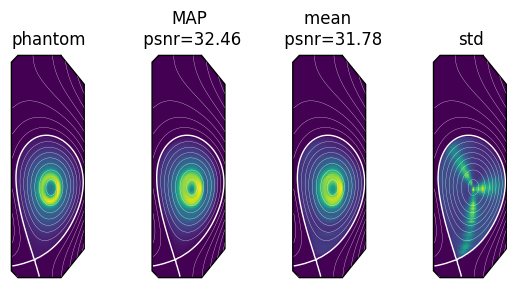

In [25]:
idx_to_be_plotted =5

noise_levels=[0.05,0.25,0.5]
noise_idx=1
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

## DMPX results

In [5]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.1, 0.5, 1.0]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_dmpx_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_dmpx_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.1
MSE (MAP): 0.000435 +- 0.0004
SSIM (MAP): 0.965926 +- 0.0196
PSNR (MAP): 34.753673 +- 3.3928
MSE (Mean): 0.000455 +- 0.0004
SSIM (Mean): 0.972372 +- 0.0168
PSNR (Mean): 34.635667 +- 3.5841
Noise level: 0.5
MSE (MAP): 0.000501 +- 0.0004
SSIM (MAP): 0.954767 +- 0.0251
PSNR (MAP): 33.956944 +- 3.1148
MSE (Mean): 0.000497 +- 0.0004
SSIM (Mean): 0.965884 +- 0.0217
PSNR (Mean): 34.003245 +- 3.2021
Noise level: 1.0
MSE (MAP): 0.000725 +- 0.0006
SSIM (MAP): 0.941535 +- 0.0314
PSNR (MAP): 32.403382 +- 3.2486
MSE (Mean): 0.000765 +- 0.0006
SSIM (Mean): 0.952542 +- 0.0297
PSNR (Mean): 32.120214 +- 3.2454


Noise level: 0.1, procedure=True
MSE (MAP): 163.121564 +- 234.3234
SSIM (MAP): 0.963125 +- 0.0207
PSNR (MAP): 34.113354 +- 3.5006
MSE (Mean): 171.758670 +- 247.1923
SSIM (Mean): 0.968980 +- 0.0185
PSNR (Mean): 33.943343 +- 3.6301
Noise level: 0.5, procedure=True
MSE (MAP): 176.838453 +- 236.0252
SSIM (MAP): 0.953728 +- 0.0255
PSNR (MAP): 33.466032 +- 2.9890
MSE (Mean): 170.6770

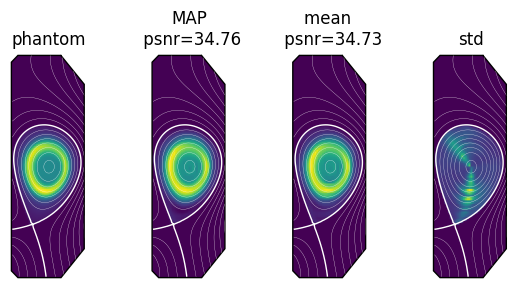

In [9]:
idx_to_be_plotted = 4
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

## Pilatus results

In [4]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.05
MSE (MAP): 0.002966 +- 0.0032
SSIM (MAP): 0.914931 +- 0.0529
PSNR (MAP): 27.165156 +- 4.2537
MSE (Mean): 0.003680 +- 0.0030
SSIM (Mean): 0.902304 +- 0.0556
PSNR (Mean): 25.396966 +- 3.2190
Noise level: 0.25
MSE (MAP): 0.001957 +- 0.0022
SSIM (MAP): 0.925928 +- 0.0458
PSNR (MAP): 29.074858 +- 4.2845
MSE (Mean): 0.002480 +- 0.0022
SSIM (Mean): 0.920290 +- 0.0510
PSNR (Mean): 27.407365 +- 3.7401
Noise level: 0.5
MSE (MAP): 0.002025 +- 0.0022
SSIM (MAP): 0.916516 +- 0.0489
PSNR (MAP): 28.857971 +- 4.2150
MSE (Mean): 0.002709 +- 0.0023
SSIM (Mean): 0.908264 +- 0.0563
PSNR (Mean): 26.945492 +- 3.6682


Noise level: 0.05, procedure=True
MSE (MAP): 1152.965886 +- 1947.7197
SSIM (MAP): 0.904944 +- 0.0612
PSNR (MAP): 26.466604 +- 4.4461
MSE (Mean): 1415.949585 +- 2088.3324
SSIM (Mean): 0.893658 +- 0.0620
PSNR (Mean): 24.856073 +- 3.4573
Noise level: 0.25, procedure=True
MSE (MAP): 783.822983 +- 1422.1455
SSIM (MAP): 0.920119 +- 0.0513
PSNR (MAP): 28.310891 +- 4.4007
MSE (Mean):

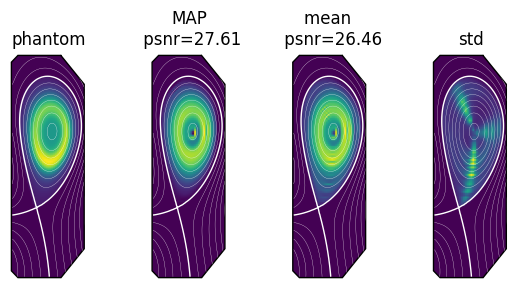

In [78]:
idx_to_be_plotted = 24
noise_idx=2
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

In [62]:
import copy
gg=copy.deepcopy(maps)

In [64]:
gg1=copy.deepcopy(maps)

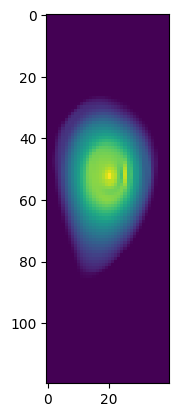

In [65]:
plt.imshow(gg1.reshape(120,40))

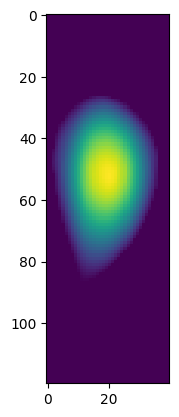

In [66]:
plt.imshow(gg)

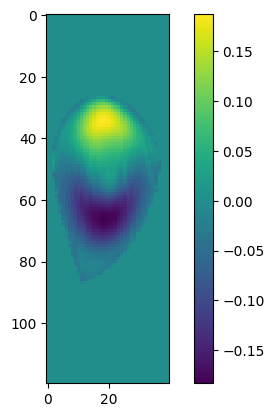

In [68]:
plt.imshow(gg-ground_truth)
plt.colorbar()

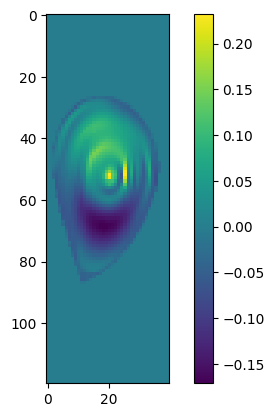

In [69]:
plt.imshow(gg1-ground_truth)
plt.colorbar()

In [70]:
print("mse, mse1", np.mean((gg-ground_truth)**2), np.mean((gg1-ground_truth)**2))

mse, mse1 0.002331918310705842 0.001615067689324765
